# 00 - Data Audit

Load all panels, verify structure, and confirm treatment coding before analysis.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

FARS_FILE = "fars_state_year.parquet"
CDC_FILE  = "cdc_state_year.parquet"

# Load FARS panel
if not (DATA_DIR / FARS_FILE).exists():
    raise FileNotFoundError(
        f"{FARS_FILE} not found. Run:\n"
        "  python scripts/download_fars.py\n"
        "  python src/build_fars_panel.py"
    )
fars = pd.read_parquet(DATA_DIR / FARS_FILE)
leg  = pd.read_csv("../data/codebooks/state_legalization_dates.csv")
print(f"FARS panel: {fars.shape}  |  States: {fars['state'].nunique()}  |  Years: {sorted(fars['year'].dropna().unique()[:3])}...{sorted(fars['year'].dropna().unique()[-3:])}")

FARS panel: (676, 11)  |  States: 51  |  Years: [np.int64(2010), np.int64(2011), np.int64(2012)]...[np.int64(2020), np.int64(2021), np.int64(2022)]


## FARS panel structure

In [2]:
print(f"Years: {sorted(fars['year'].dropna().unique())}")
print(f"\nTreatment breakdown:")
cohorts = (
    leg[leg['retail_sales_year'].notna()]
    .groupby('retail_sales_year')['state'].apply(list)
    .sort_index()
)
for yr, states in cohorts.items():
    print(f"  {int(yr)}: {', '.join(states)}")
print(f"\nNever treated: {leg[leg['retail_sales_year'].isna()]['state'].nunique()} states")

Years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Treatment breakdown:
  2014: Colorado, Washington
  2015: Oregon
  2016: Alaska
  2017: Nevada
  2018: California, Massachusetts
  2019: Michigan
  2020: Maine, Illinois
  2021: Arizona, New Mexico
  2022: Vermont, Montana, New Jersey, Connecticut, Rhode Island, New York
  2023: Maryland, Missouri, South Dakota
  2024: Virginia, Ohio
  2025: Minnesota

Never treated: 28 states


## Check for missing outcomes

In [3]:
outcome_cols = [c for c in fars.columns if 'fatalities' in c or 'per_100k' in c]
print("Missing values in outcome columns:")
print(fars[outcome_cols].isnull().sum())

Missing values in outcome columns:
total_fatalities             0
total_fatalities_per_100k    0
dtype: int64


## CDC panel (if available)

In [4]:
try:
    cdc = pd.read_parquet(DATA_DIR / CDC_FILE)
    print(f"CDC panel: {cdc.shape}")
    print(cdc[["state","year","overdose_deaths_per_100k"]].describe())
except FileNotFoundError:
    print("CDC panel not yet built. Run: python src/build_cdc_panel.py")

CDC panel: (408, 6)
              year  overdose_deaths_per_100k
count   408.000000                407.000000
mean   2013.500000                 16.553071
std       2.294101                  7.362716
min    2010.000000                  2.800000
25%    2011.750000                 11.700000
50%    2013.500000                 14.800000
75%    2015.250000                 19.850000
max    2017.000000                 53.600000


## NYC 311 panel (if available)

In [5]:
try:
    nyc_311 = pd.read_parquet(DATA_DIR / "nyc_311_zip_month.parquet")
    disp     = pd.read_parquet(DATA_DIR / "nyc_dispensary_events.parquet")
    print(f"311 panel: {nyc_311.shape}  |  Zips: {nyc_311['zip'].nunique()}")
    print(f"Dispensaries: {len(disp)}")
except FileNotFoundError as e:
    print(f"NYC 311 data not yet built: {e}")

311 panel: (8343, 8)  |  Zips: 235
Dispensaries: 51


## Treatment rollout

Staggered adoption is the whole identification story: states switch on recreational retail sales in different years, which is what lets Callaway–Sant'Anna form clean cohort comparisons. Here is the rollout.

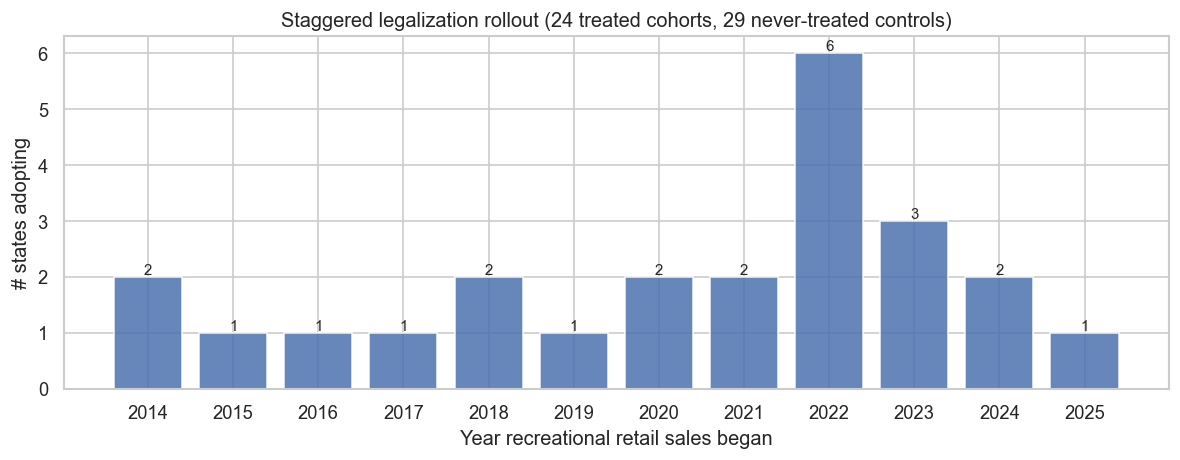

In [6]:
roll = leg[leg["retail_sales_year"].notna()].copy()
roll["retail_sales_year"] = roll["retail_sales_year"].astype(int)
counts = roll.groupby("retail_sales_year").size()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(counts.index, counts.values, color="#4C72B0", alpha=0.85)
for x,v in counts.items():
    ax.text(x, v+0.05, str(v), ha="center", fontsize=9)
ax.set_xlabel("Year recreational retail sales began")
ax.set_ylabel("# states adopting")
n_never = leg["retail_sales_year"].isna().sum()
ax.set_title(f"Staggered legalization rollout ({roll.shape[0]} treated cohorts, {n_never} never-treated controls)")
ax.set_xticks(range(int(counts.index.min()), int(counts.index.max())+1))
plt.tight_layout(); plt.savefig(OUT_DIR/"00_treatment_rollout.png", bbox_inches="tight"); plt.show()

**Takeaway.** Treatment timing spans 2014–2024 with a large never-treated control pool — the staggered structure that makes a cohort-aware estimator (notebook 05) necessary and a single pooled TWFE coefficient (notebook 04) potentially biased.